# Gold Price Prediction — Modeling Challenges in Non-Stationary Financial Time Series

## Abstract

This project investigates various machine-learning approaches for gold price prediction. It focuses on understanding how different validation strategies influence model reliability. The notebook combines feature engineering (lags, rolling means) with both linear and ensemble regressors.  
Initial time-series experiments revealed the fundamental challenge of financial forecasting — excellent fit on historical data but catastrophic failure on forward predictions.

#### 1. Load libraries

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeRegressor, export_text, export_graphviz
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, PolynomialFeatures 
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso
from sklearn.metrics import classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import linregress
import yfinance as yf
import pandas as pd
from datetime import datetime
import statsmodels.api as sm
import time, logging, os, warnings, joblib, pydot
from DataScrapper import DataScrapper
from xgboost import XGBRegressor
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier


#### 2. Collect important data

##### Yahoo Finance Tickers Overview

| Key | Yahoo Ticker | Description | Category |
|-----|---------------|--------------|-----------|
| **Gold** | `GC=F` | Futures contract for **Gold** traded on COMEX (CME Group). Quoted in **USD per troy ounce**. Often used as a hedge against inflation and market uncertainty. | Commodity |
| **Silver** | `SI=F` | Futures contract for **Silver** traded on COMEX (CME Group). Quoted in **USD per troy ounce**. Used both industrially and as an investment metal. | Commodity |
| **Oil** | `CL=F` | Futures contract for **Crude Oil (WTI)** traded on NYMEX (CME Group). Quoted in **USD per barrel**. Key benchmark for global energy prices. | Commodity |
| **SP500** | `^GSPC` | The **S&P 500 Index**, tracking 500 of the largest publicly traded companies in the United States. Benchmark for the U.S. equity market. | Stock Index |
| **MSCI_Europe** | `IEUR` | **iShares MSCI Europe ETF**, providing exposure to large and mid-cap companies across 15 developed European markets. Issuer: BlackRock. | ETF / Stock Index |
| **Euro_STOXX_50** | `^STOXX50E` | The **Euro Stoxx 50 Index**, representing 50 leading companies from the Eurozone. Common benchmark for European equities. | Stock Index |
| **DAX** | `^GDAXI` | The **DAX Index**, consisting of 40 major German blue-chip companies traded on the Frankfurt Stock Exchange (Deutsche Börse). | Stock Index |
| **USDPLN** | `PLN=X` | **USD/PLN exchange rate**, showing how many Polish zloty (PLN) equal one U.S. dollar (USD). | Forex / Currency |
| **EURUSD** | `EURUSD=X` | **EUR/USD exchange rate**, the world’s most traded currency pair, showing how many U.S. dollars equal one euro. | Forex / Currency |
| **USDGBP** | `GBPUSD=X` | **GBP/USD exchange rate**, also known as “Cable.” Shows how many U.S. dollars equal one British pound sterling. | Forex / Currency |


In [9]:
tickers = {
    'Gold' : 'GC=F',
    'Silver' : 'SI=F',
    'Oil' : 'CL=F',
    'SP500' : '^GSPC',
    'MSCI_Europe' : 'IEUR',
    'Euro_STOXX_50' : '^STOXX50E',
    'DAX' : '^GDAXI',
    'USDPLN' : 'PLN=X',
    'EURUSD' : 'EURUSD=X',
    'USDGBP' : 'GBPUSD=X'    
}

Fetching data from [YahooFinance](https://finance.yahoo.com/?guccounter=1) with provided library.

In [10]:
data_fetcher = DataScrapper(tickers)

I found up that oldest data are from 2010, so i decided to pick start date as 2010.

In [11]:
start_date = '2010-01-01'
end_date = datetime.now().strftime('%Y-%m-%d')

In [12]:
data_fetcher.download(start_date, end_date)

2025-12-01 17:44:02,561 - Starting bulk data download...
[*********************100%***********************]  10 of 10 completed
2025-12-01 17:44:02,779 - Bulk download completed. Processing data...
2025-12-01 17:44:02,834 - Data saved to data/financial_data_2010-01-01_2025-12-01.csv
2025-12-01 17:44:02,834 - Dataset shape: (4149, 10)
2025-12-01 17:44:02,835 - Columns: ['Gold', 'Silver', 'Oil', 'SP500', 'MSCI_Europe', 'Euro_STOXX_50', 'DAX', 'USDPLN', 'EURUSD', 'USDGBP']
2025-12-01 17:44:02,835 - Date range: 2010-01-01 00:00:00 to 2025-11-28 00:00:00
2025-12-01 17:44:02,835 - Columns included:
2025-12-01 17:44:02,836 - - Gold
2025-12-01 17:44:02,836 - - Silver
2025-12-01 17:44:02,836 - - Oil
2025-12-01 17:44:02,836 - - SP500
2025-12-01 17:44:02,836 - - MSCI_Europe
2025-12-01 17:44:02,837 - - Euro_STOXX_50
2025-12-01 17:44:02,837 - - DAX
2025-12-01 17:44:02,837 - - USDPLN
2025-12-01 17:44:02,837 - - EURUSD
2025-12-01 17:44:02,837 - - USDGBP


#### 3. Load data to frame

Loading collected data from a CSV file

In [12]:
df = pd.read_csv('data/financial_data_2010-01-01_2025-10-30.csv', index_col=0, parse_dates=True)

#### 4. Data maintance

Preparing data:
- removing columns that have lot of NaN values,
- removing rows populated with NaN values.

In [13]:
df.head(10)

,Gold,Silver,Oil,SP500,MSCI_Europe,Euro_STOXX_50,DAX,USDPLN,EURUSD,USDGBP
Date,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.8415,1.438994,1.613294
2010-01-04,1117.699951,17.440001,81.510002,1132.989990,NaN,3017.800049,6048.299805,2.8250,1.442398,1.611370
2010-01-05,1118.099976,17.781000,81.769997,1136.520020,NaN,3012.360107,6031.859863,2.8453,1.436596,1.599079
2010-01-06,1135.900024,18.163000,83.180000,1137.140015,NaN,3009.659912,6034.330078,2.8379,1.440403,1.602384
2010-01-07,1133.099976,18.333000,82.660004,1141.689941,NaN,3007.340088,6019.359863,2.8673,1.431803,1.593397
2010-01-08,1138.199951,18.458000,82.750000,1144.979980,NaN,3017.850098,6037.609863,2.8182,1.441109,1.602410
2010-01-11,1150.699951,18.683001,82.519997,1146.979980,NaN,3010.239990,6040.500000,2.7980,1.451126,1.611292
2010-01-12,1128.900024,18.243000,80.790001,1136.219971,NaN,2976.889893,5943.000000,2.8122,1.447660,1.615170
2010-01-13,1136.400024,18.538000,79.650002,1145.680054,NaN,2978.409912,5963.140137,2.7868,1.452391,1.628611


Checking data formats, and population of data in columns.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4127 entries, 2010-01-01 to 2025-10-29
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Gold           4126 non-null   float64
 1   Silver         4126 non-null   float64
 2   Oil            4126 non-null   float64
 3   SP500          4126 non-null   float64
 4   MSCI_Europe    2968 non-null   float64
 5   Euro_STOXX_50  4126 non-null   float64
 6   DAX            4126 non-null   float64
 7   USDPLN         4127 non-null   float64
 8   EURUSD         4127 non-null   float64
 9   USDGBP         4127 non-null   float64
dtypes: float64(10)
memory usage: 354.7 KB


Sum of all NaN's in each column.

In [14]:
df.isna().sum()

Gold                1
Silver              1
Oil                 1
SP500               1
MSCI_Europe      1159
Euro_STOXX_50       1
DAX                 1
USDPLN              0
EURUSD              0
USDGBP              0
dtype: int64

We have big part of data missing from MSCI Europe so we will drop this column

In [15]:
df = df.drop(columns=['MSCI_Europe'])

Removing row if there's all NaN value.

In [17]:
df = df.drop(df.index[df.isna().any(axis=1)])

#### Data analysis

In [9]:
df.describe() # yield basic statistics from the data

,Gold,Silver,Oil,SP500,Euro_STOXX_50,DAX,USDPLN,EURUSD,USDGBP
count,4126.000000,4126.000000,4126.000000,4126.000000,4126.000000,4126.000000,4127.000000,4127.000000,4127.000000
mean,1635.370455,22.768528,71.677855,2903.568351,3482.165221,12007.528986,3.663070,1.186725,1.405369
std,523.344270,7.056333,20.858635,1443.545621,778.761689,4294.865879,0.452304,0.112628,0.149136
min,1050.800049,11.735000,-37.630001,1022.580017,1995.010010,5072.330078,2.643400,0.959619,1.072754
25%,1267.325043,16.994250,53.995001,1797.310028,2947.355042,9042.479980,3.266450,1.097508,1.278339
50%,1499.299988,21.098001,71.820000,2560.829956,3368.954956,11901.845215,3.755510,1.154694,1.354115
75%,1820.374969,27.367000,88.444998,4007.552490,3844.634949,14300.237305,3.958439,1.286447,1.554497
max,4336.399902,53.022999,123.699997,6890.890137,5711.060059,24611.250000,5.001400,1.484406,1.716090


Checking if data starts at 2010 and ends at 2025

Display first 10 rwos.

In [18]:
display(df.head(10))

,Gold,Silver,Oil,SP500,Euro_STOXX_50,DAX,USDPLN,EURUSD,USDGBP
Date,,,,,,,,,
2010-01-04,1117.699951,17.440001,81.510002,1132.989990,3017.800049,6048.299805,2.8250,1.442398,1.611370
2010-01-05,1118.099976,17.781000,81.769997,1136.520020,3012.360107,6031.859863,2.8453,1.436596,1.599079
2010-01-06,1135.900024,18.163000,83.180000,1137.140015,3009.659912,6034.330078,2.8379,1.440403,1.602384
2010-01-07,1133.099976,18.333000,82.660004,1141.689941,3007.340088,6019.359863,2.8673,1.431803,1.593397
2010-01-08,1138.199951,18.458000,82.750000,1144.979980,3017.850098,6037.609863,2.8182,1.441109,1.602410
2010-01-11,1150.699951,18.683001,82.519997,1146.979980,3010.239990,6040.500000,2.7980,1.451126,1.611292
2010-01-12,1128.900024,18.243000,80.790001,1136.219971,2976.889893,5943.000000,2.8122,1.447660,1.615170
2010-01-13,1136.400024,18.538000,79.650002,1145.680054,2978.409912,5963.140137,2.7868,1.452391,1.628611
2010-01-14,1142.599976,18.643000,79.389999,1148.459961,2989.709961,5988.879883,2.7904,1.449990,1.633400


Display last 10 rows.

In [19]:
df.tail(10)

,Gold,Silver,Oil,SP500,Euro_STOXX_50,DAX,USDPLN,EURUSD,USDGBP
Date,,,,,,,,,
2025-10-16,4280.200195,53.022999,57.459999,6629.069824,5652.009766,24272.189453,3.650790,1.164632,1.340447
2025-10-17,4189.899902,49.863998,57.540001,6664.009766,5607.390137,23830.990234,3.628690,1.169960,1.344556
2025-10-20,4336.399902,51.118999,57.520000,6735.129883,5680.930176,24258.800781,3.640125,1.165746,1.342588
2025-10-21,4087.699951,47.450001,57.820000,6735.350098,5686.830078,24330.029297,3.635263,1.164443,1.340518
2025-10-22,4044.399902,47.460999,58.500000,6699.399902,5639.209961,24151.130859,3.652491,1.160039,1.336523
2025-10-23,4125.500000,48.481998,61.790001,6738.439941,5668.330078,24207.789062,3.643020,1.160847,1.335185
2025-10-24,4118.399902,48.376999,61.500000,6791.689941,5674.500000,24239.890625,3.640170,1.161805,1.332747
2025-10-27,4001.899902,46.562000,61.310001,6875.160156,5711.060059,24308.779297,3.644842,1.163169,1.332239
2025-10-28,3966.199951,47.125000,60.150002,6890.890137,5704.350098,24278.630859,3.632601,1.165175,1.334100


Make sure that there's no NaN values.

In [20]:
df.isna().sum()

Gold             0
Silver           0
Oil              0
SP500            0
Euro_STOXX_50    0
DAX              0
USDPLN           0
EURUSD           0
USDGBP           0
dtype: int64

Set all data to represent prices in USD.

In [24]:
# Data is clean, now we have to calculate so erverythin will be in USD
df_unified = df.copy()
df_unified['Euro_STOXX_50'] = df_unified['Euro_STOXX_50'] * df_unified['EURUSD'] # Convert Euro STOXX 50 from EUR to USD
df_unified['DAX'] = df_unified['DAX'] * df_unified['EURUSD'] # Convert DAX from EUR to USD

In [25]:
df_unified.describe()

,Gold,Silver,Oil,SP500,Euro_STOXX_50,DAX,USDPLN,EURUSD,USDGBP
count,4126.000000,4126.000000,4126.000000,4126.000000,4126.000000,4126.000000,4126.000000,4126.000000,4126.000000
mean,1635.370455,22.768528,71.677855,2903.568351,4081.121364,13940.130265,3.663269,1.186664,1.405318
std,523.344270,7.056333,20.858635,1443.545621,746.742557,4373.591136,0.452178,0.112573,0.149119
min,1050.800049,11.735000,-37.630001,1022.580017,2557.374000,6883.474131,2.643400,0.959619,1.072754
25%,1267.325043,16.994250,53.995001,1797.310028,3570.243302,10986.143868,3.266550,1.097505,1.278286
50%,1499.299988,21.098001,71.820000,2560.829956,3971.801403,13171.347605,3.755515,1.154514,1.353968
75%,1820.374969,27.367000,88.444998,4007.552490,4408.124272,16106.234112,3.958619,1.286294,1.554436
max,4336.399902,53.022999,123.699997,6890.890137,6651.756365,28783.294833,5.001400,1.484406,1.716090


In [26]:
df_unified.head()

,Gold,Silver,Oil,SP500,Euro_STOXX_50,DAX,USDPLN,EURUSD,USDGBP
Date,,,,,,,,,
2010-01-04,1117.699951,17.440001,81.510002,1132.989990,4352.868250,8724.054531,2.8250,1.442398,1.611370
2010-01-05,1118.099976,17.781000,81.769997,1136.520020,4327.544230,8665.345250,2.8453,1.436596,1.599079
2010-01-06,1135.900024,18.163000,83.180000,1137.140015,4335.124196,8691.869213,2.8379,1.440403,1.602384
2010-01-07,1133.099976,18.333000,82.660004,1141.689941,4305.919241,8618.538874,2.8673,1.431803,1.593397
2010-01-08,1138.199951,18.458000,82.750000,1144.979980,4349.051121,8700.854282,2.8182,1.441109,1.602410


Everything is in USD now, so we can save the final dataset

In [27]:
df_unified.to_csv('data/financial_data_usd_2010-01-01_2025-10-03.csv', encoding='utf-8')

Load prepared dataset.

In [21]:
prepared_df = pd.read_csv('data/financial_data_usd_2010-01-01_2025-10-03.csv', index_col=0, parse_dates=True)

In [22]:
prepared_df

,Gold,Silver,Oil,SP500,Euro_STOXX_50,DAX,USDPLN,EURUSD,USDGBP
Date,,,,,,,,,
2010-01-04,1117.699951,17.440001,81.510002,1132.989990,4352.868250,8724.054531,2.825000,1.442398,1.611370
2010-01-05,1118.099976,17.781000,81.769997,1136.520020,4327.544230,8665.345250,2.845300,1.436596,1.599079
2010-01-06,1135.900024,18.163000,83.180000,1137.140015,4335.124196,8691.869213,2.837900,1.440403,1.602384
2010-01-07,1133.099976,18.333000,82.660004,1141.689941,4305.919241,8618.538874,2.867300,1.431803,1.593397
2010-01-08,1138.199951,18.458000,82.750000,1144.979980,4349.051121,8700.854282,2.818200,1.441109,1.602410
...,...,...,...,...,...,...,...,...,...
2025-10-23,4125.500000,48.481998,61.790001,6738.439941,6580.063675,28101.538066,3.643020,1.160847,1.335185
2025-10-24,4118.399902,48.376999,61.500000,6791.689941,6592.659958,28162.015386,3.640170,1.161805,1.332747
2025-10-27,4001.899902,46.562000,61.310001,6875.160156,6642.930210,28275.227841,3.644842,1.163169,1.332239


In [24]:
prepared_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4126 entries, 2010-01-04 to 2025-10-29
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Gold           4126 non-null   float64
 1   Silver         4126 non-null   float64
 2   Oil            4126 non-null   float64
 3   SP500          4126 non-null   float64
 4   Euro_STOXX_50  4126 non-null   float64
 5   DAX            4126 non-null   float64
 6   USDPLN         4126 non-null   float64
 7   EURUSD         4126 non-null   float64
 8   USDGBP         4126 non-null   float64
dtypes: float64(9)
memory usage: 322.3 KB


Split dataset for train and test set. Decided to set everything before 2025 to
be train data.

Starting from 2025 data will be test data.

In [25]:
train_df = prepared_df[prepared_df.index.year < 2025]

In [26]:
test_df = prepared_df[prepared_df.index.year >= 2025]

Checking the correctness of data division.

In [27]:
test_df

,Gold,Silver,Oil,SP500,Euro_STOXX_50,DAX,USDPLN,EURUSD,USDGBP
Date,,,,,,,,,
2025-01-02,2658.899902,29.622000,73.129997,5868.549805,5040.610518,20729.248896,4.128580,1.035186,1.251925
2025-01-03,2645.000000,29.806000,73.959999,5942.470215,5002.105122,20439.971904,4.159400,1.026821,1.238022
2025-01-06,2638.399902,30.341999,73.559998,5975.379883,5138.905918,20833.485628,4.141060,1.030535,1.242684
2025-01-07,2656.699951,30.447001,74.250000,5909.029785,5205.462912,21126.474632,4.091800,1.038637,1.251095
2025-01-08,2664.500000,30.452000,73.320000,5918.250000,5169.036020,21032.422699,4.116860,1.034554,1.247785
...,...,...,...,...,...,...,...,...,...
2025-10-23,4125.500000,48.481998,61.790001,6738.439941,6580.063675,28101.538066,3.643020,1.160847,1.335185
2025-10-24,4118.399902,48.376999,61.500000,6791.689941,6592.659958,28162.015386,3.640170,1.161805,1.332747
2025-10-27,4001.899902,46.562000,61.310001,6875.160156,6642.930210,28275.227841,3.644842,1.163169,1.332239


In [28]:
train_df

,Gold,Silver,Oil,SP500,Euro_STOXX_50,DAX,USDPLN,EURUSD,USDGBP
Date,,,,,,,,,
2010-01-04,1117.699951,17.440001,81.510002,1132.989990,4352.868250,8724.054531,2.825000,1.442398,1.611370
2010-01-05,1118.099976,17.781000,81.769997,1136.520020,4327.544230,8665.345250,2.845300,1.436596,1.599079
2010-01-06,1135.900024,18.163000,83.180000,1137.140015,4335.124196,8691.869213,2.837900,1.440403,1.602384
2010-01-07,1133.099976,18.333000,82.660004,1141.689941,4305.919241,8618.538874,2.867300,1.431803,1.593397
2010-01-08,1138.199951,18.458000,82.750000,1144.979980,4349.051121,8700.854282,2.818200,1.441109,1.602410
...,...,...,...,...,...,...,...,...,...
2024-12-25,2620.000000,29.974001,70.099998,6040.040039,5048.299103,20647.839921,4.087380,1.040258,1.253604
2024-12-26,2638.800049,30.047001,69.620003,6037.589844,5046.829676,20641.829880,4.088420,1.039955,1.254375
2024-12-27,2617.199951,29.655001,70.599998,5970.839844,5106.191199,20830.018892,4.088500,1.042318,1.252976


Creating X, Y for train and test sets.

In [29]:
X_train = train_df.drop(columns=['Gold'])
y_train = train_df['Gold']

In [30]:
X_test = test_df.drop(columns=['Gold'])
y_test = test_df['Gold']

Checking shape of X & Y sets from train and test sets, and making sure that X & Y are properly assingned.

In [31]:
X_train.shape

(3912, 8)

In [32]:
X_train.tail()

,Silver,Oil,SP500,Euro_STOXX_50,DAX,USDPLN,EURUSD,USDGBP
Date,,,,,,,,
2024-12-25,29.974001,70.099998,6040.040039,5048.299103,20647.839921,4.087380,1.040258,1.253604
2024-12-26,30.047001,69.620003,6037.589844,5046.829676,20641.829880,4.088420,1.039955,1.254375
2024-12-27,29.655001,70.599998,5970.839844,5106.191199,20830.018892,4.088500,1.042318,1.252976
2024-12-30,29.106001,70.989998,5906.939941,5078.355730,20763.994439,4.092367,1.042938,1.257881
2024-12-31,28.940001,71.720001,5881.629883,5067.046562,20717.754373,4.107070,1.040615,1.254910


In [33]:
X_test.head()

,Silver,Oil,SP500,Euro_STOXX_50,DAX,USDPLN,EURUSD,USDGBP
Date,,,,,,,,
2025-01-02,29.622000,73.129997,5868.549805,5040.610518,20729.248896,4.12858,1.035186,1.251925
2025-01-03,29.806000,73.959999,5942.470215,5002.105122,20439.971904,4.15940,1.026821,1.238022
2025-01-06,30.341999,73.559998,5975.379883,5138.905918,20833.485628,4.14106,1.030535,1.242684
2025-01-07,30.447001,74.250000,5909.029785,5205.462912,21126.474632,4.09180,1.038637,1.251095
2025-01-08,30.452000,73.320000,5918.250000,5169.036020,21032.422699,4.11686,1.034554,1.247785


Checking timeseries:
- simple format %Y-%m-%d,
- range.

In [34]:
X_train.index

DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2024-12-18', '2024-12-19', '2024-12-20', '2024-12-23',
               '2024-12-24', '2024-12-25', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=3912, freq=None)

In [35]:
y_train.shape

(3912,)

Visualization of the gold price time series over the training set time horizon.

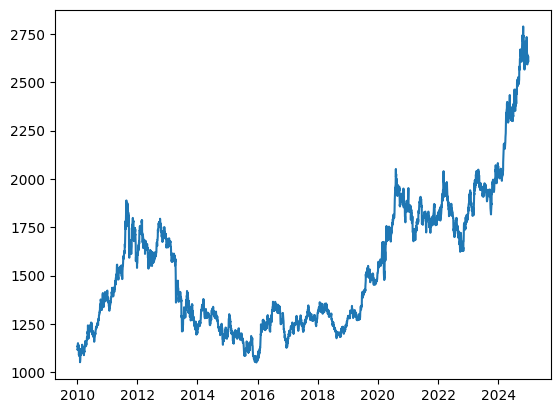

In [36]:
plt.plot(X_train.index, y_train)
plt.show()

Data histogram.

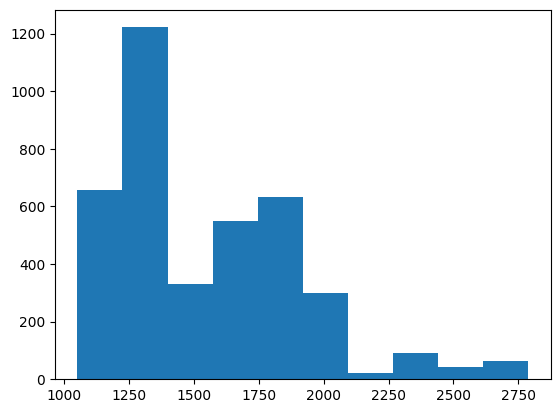

In [37]:
plt.hist(y_train)
plt.show()

Gold does not have a normal decomposition.

#### Data seasonality

##### Formal test: regression with dummy variables

Logarithmic rates of return were used to remove the trend and approximate the stationarity of the analyzed processes.

In [47]:
returns = np.log(df["Gold"] / df["Gold"].shift(1)).dropna()

In [49]:
returns = np.log(df["Gold"]).diff().dropna()

In [50]:
season_df = pd.DataFrame({
    "ret": returns,
    "dow": returns.index.dayofweek,   # 0=Mon
    "month": returns.index.month,
    "year": returns.index.year
})

2025-12-16 10:40:08,487 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-12-16 10:40:08,494 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


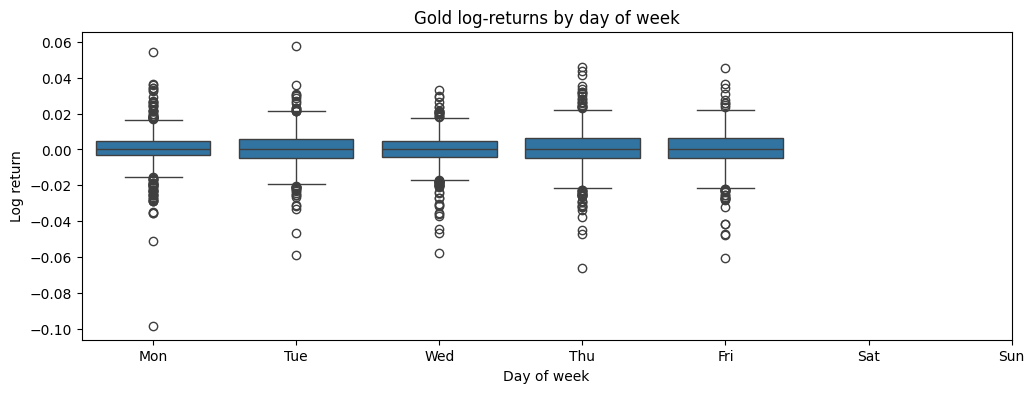

In [51]:
plt.figure(figsize=(12,4))
sns.boxplot(
    x="dow",
    y="ret",
    data=season_df
)
plt.xticks(
    ticks=range(7),
    labels=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
)
plt.title("Gold log-returns by day of week")
plt.xlabel("Day of week")
plt.ylabel("Log return")
plt.show()

2025-12-16 10:40:36,758 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-12-16 10:40:36,765 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


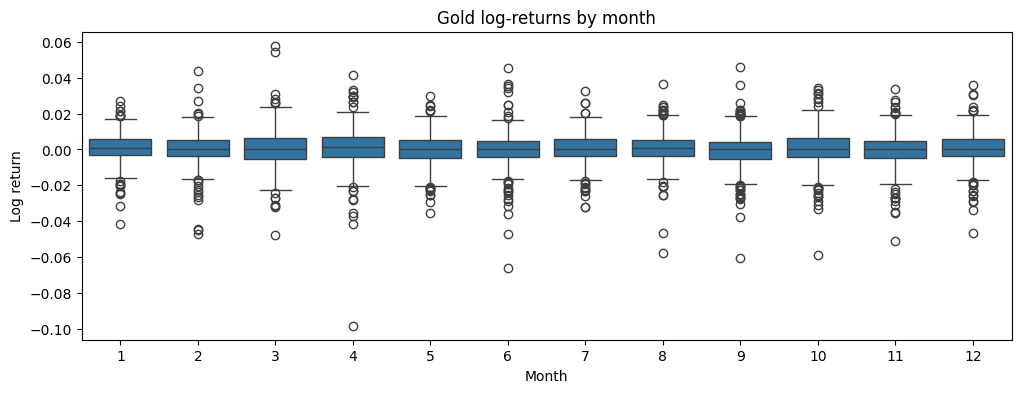

In [52]:
plt.figure(figsize=(12,4))
sns.boxplot(
    x="month",
    y="ret",
    data=season_df
)
plt.title("Gold log-returns by month")
plt.xlabel("Month")
plt.ylabel("Log return")
plt.show()

2025-12-16 10:41:13,508 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-12-16 10:41:13,514 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


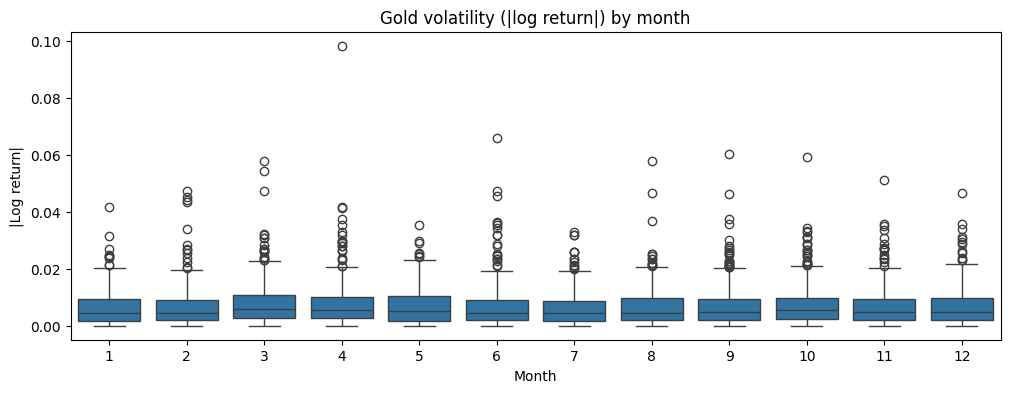

In [53]:
season_df["abs_ret"] = season_df["ret"].abs()

plt.figure(figsize=(12,4))
sns.boxplot(
    x="month",
    y="abs_ret",
    data=season_df
)
plt.title("Gold volatility (|log return|) by month")
plt.xlabel("Month")
plt.ylabel("|Log return|")
plt.show()

In [55]:
y = season_df["ret"].astype(float)
X = pd.get_dummies(
    season_df["month"],
    drop_first=True
).astype(float)
X = sm.add_constant(X, has_constant="add")
X = X.loc[y.index]


model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":5})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.452
Date:                Tue, 16 Dec 2025   Prob (F-statistic):              0.142
Time:                        10:44:20   Log-Likelihood:                 13120.
No. Observations:                4125   AIC:                        -2.622e+04
Df Residuals:                    4113   BIC:                        -2.614e+04
Df Model:                          11                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011      0.000      2.569      0.0

In [56]:
R = np.eye(X.shape[1])[1:]
model.f_test(R)

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=1.4524872286017174, p=0.14247849725778697, df_denom=4.11e+03, df_num=11>

No statistically significant monthly seasonality in average gold returns.

Single significant coefficients may result from random fluctuations and do not constitute evidence of systematic seasonality.

`const = 0.0011`

The intercept corresponds to the average daily return in the base month (January).

Boxplots were used as an exploratory data analysis (EDA) tool to visually assess potential calendar effects. Due to the high variability and the presence of outliers, visual differences between months are limited and do not allow for clear inferences about seasonality.

Formal seasonality analysis was performed using linear regression with dummy variables for months.

#### Data correlation

Visualization of data correlations between variables.

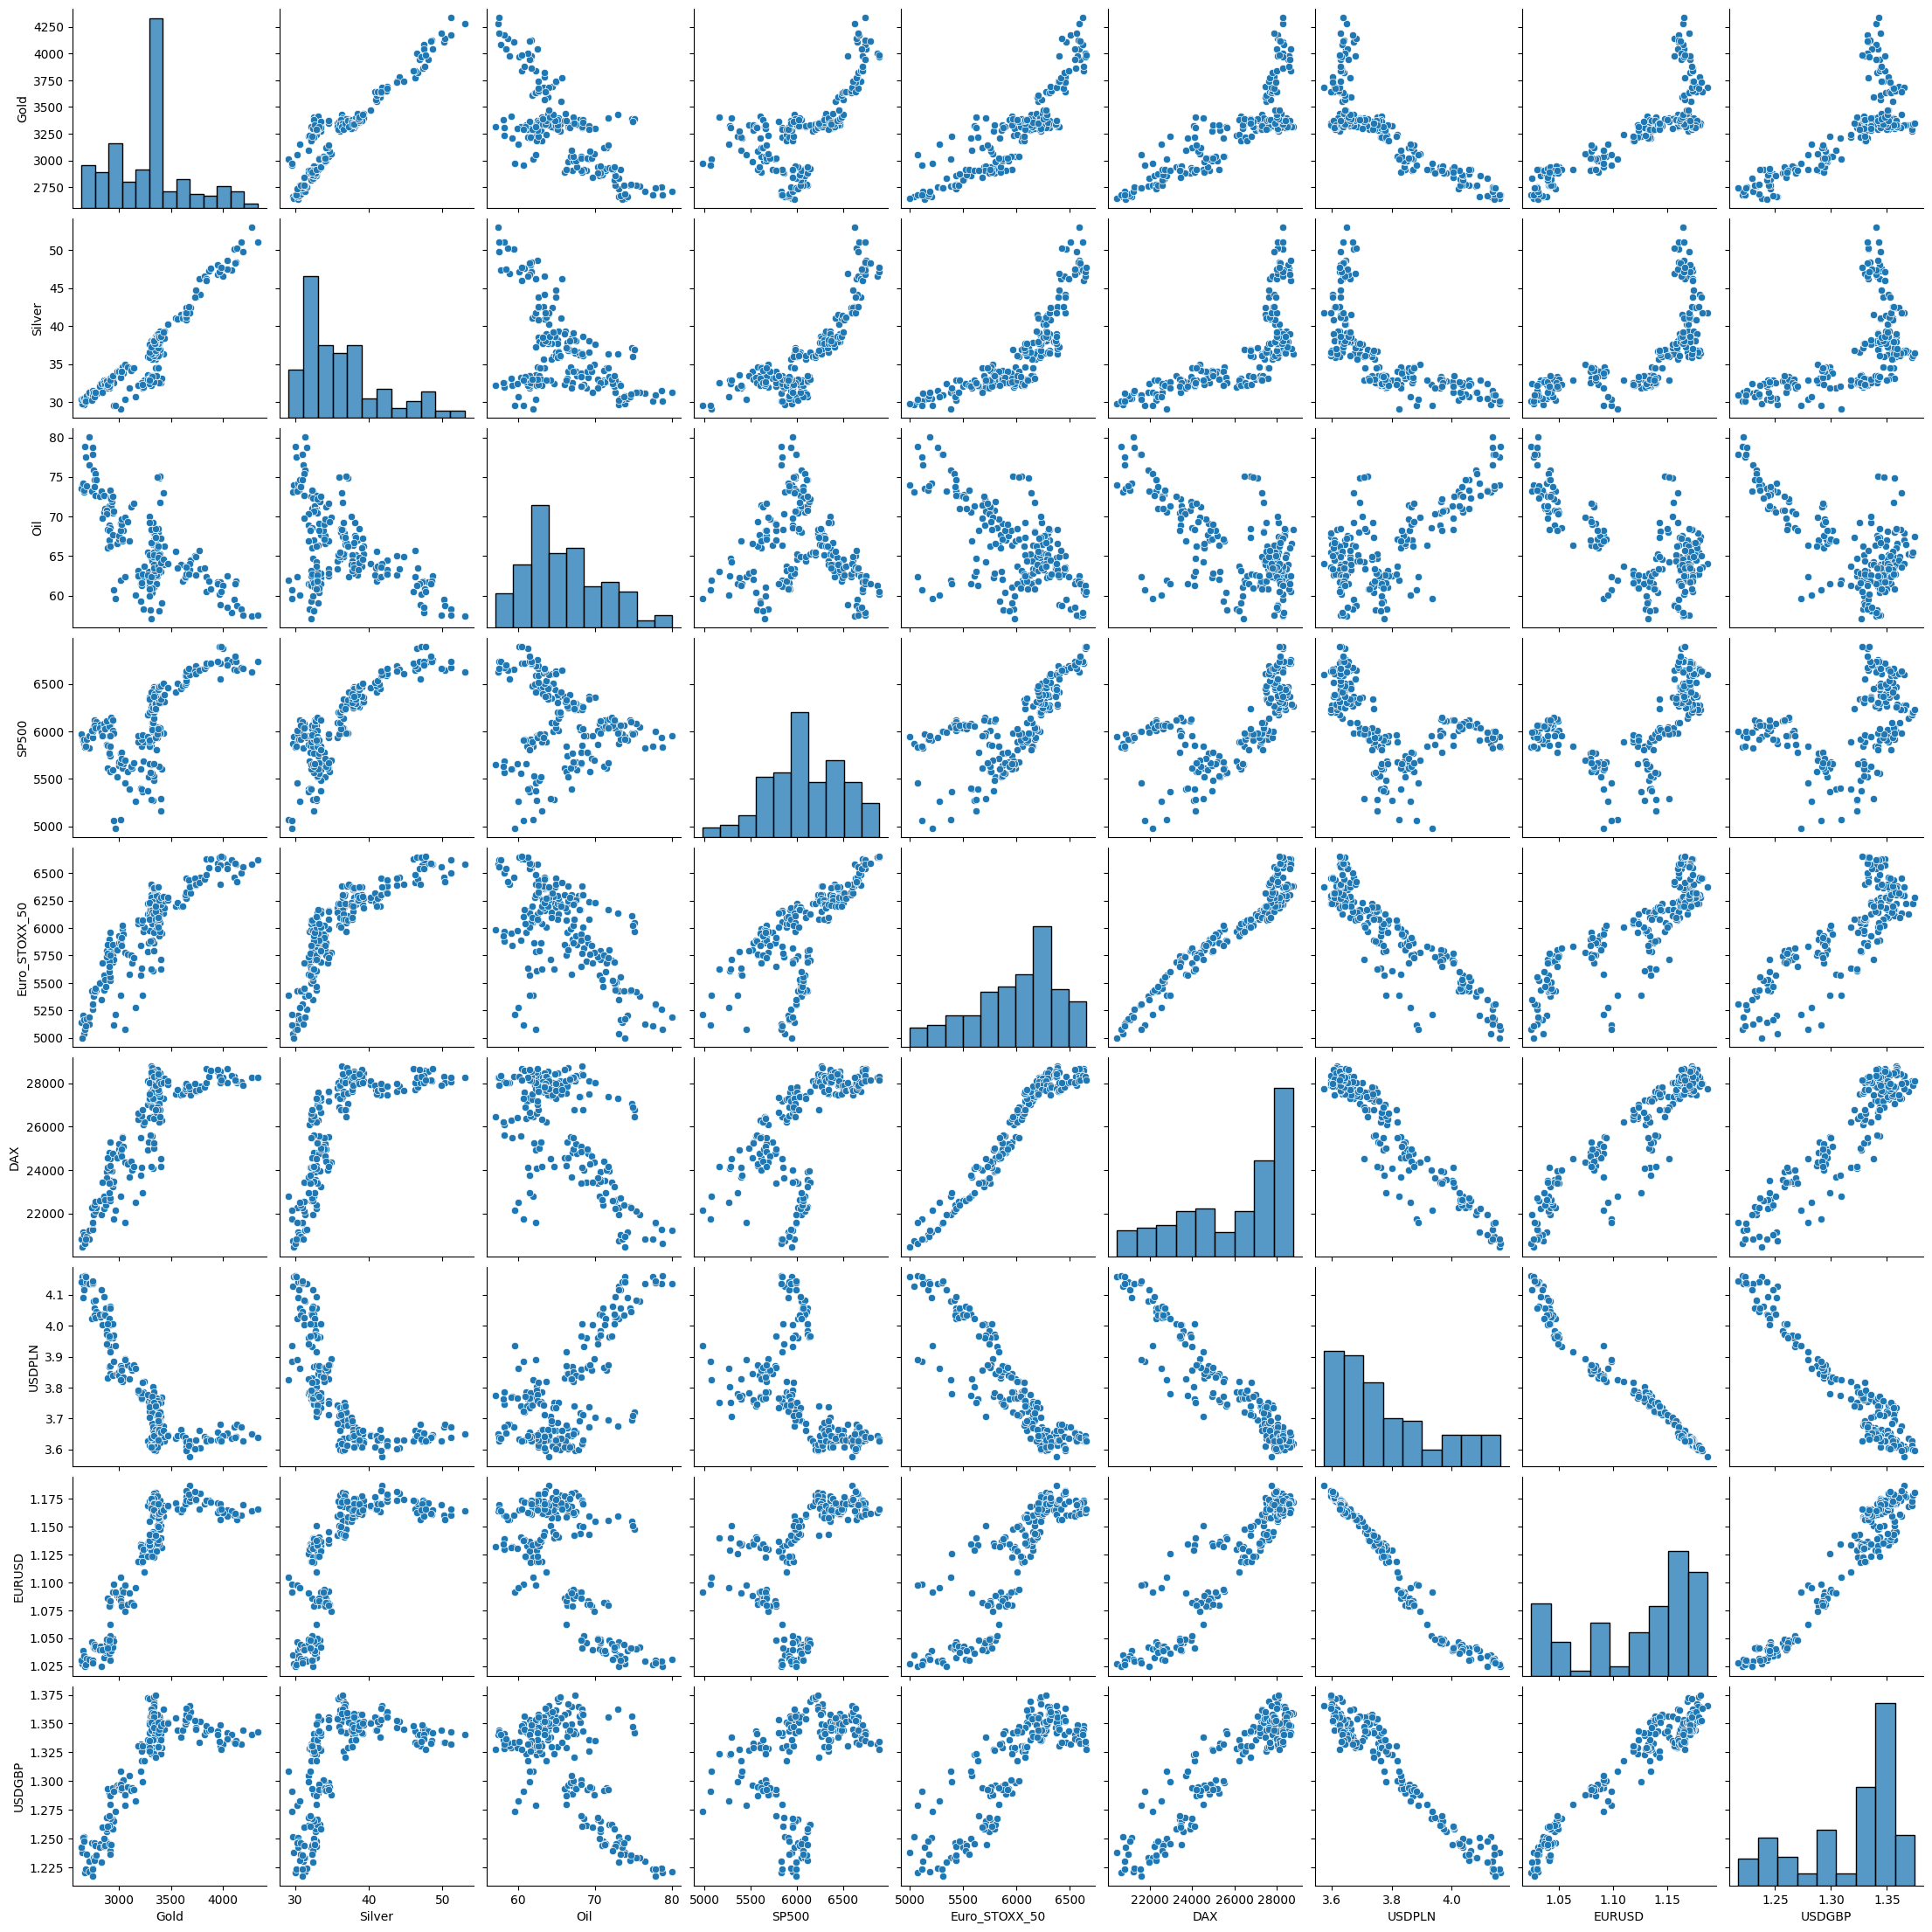

In [62]:
sns.pairplot(test_df)
plt.show()

Dependence of the correlation of variables on the gold price.

In [63]:
corr_matrix = test_df.corr()['Gold'].round(2)

In [64]:
corr_matrix

Gold             1.00
Silver           0.92
Oil             -0.71
SP500            0.65
Euro_STOXX_50    0.86
DAX              0.81
USDPLN          -0.82
EURUSD           0.83
USDGBP           0.75
Name: Gold, dtype: float64

Visualization of correlations of all variables.

In [65]:
corr_matrix_df = test_df.corr().round(2)

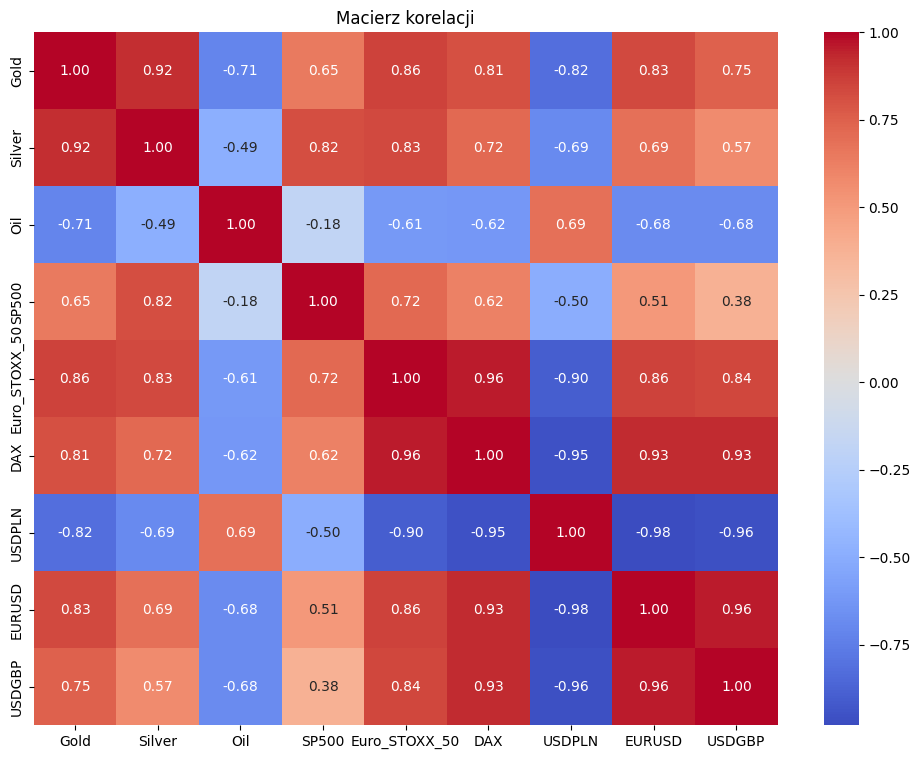

In [66]:
plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Macierz korelacji')
plt.show()

In [67]:
# fit a multiple regression model
X_train_with_const = sm.add_constant(X_train, prepend=True, has_constant='skip')
X_test_with_const =  sm.add_constant(X_test, prepend=True, has_constant='skip')

model_full = sm.OLS(endog=y_train, exog=X_train_with_const)
fitted_model_full = model_full.fit()
fitted_model_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Gold   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     7000.
Date:                Tue, 16 Dec 2025   Prob (F-statistic):               0.00
Time:                        11:18:49   Log-Likelihood:                -23138.
No. Observations:                3912   AIC:                         4.629e+04
Df Residuals:                    3903   BIC:                         4.635e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          2132.6175    109.800     19.423      0.000    1917.348    2347.887
Silver           28.7216      0.339     84.733      0.000      28.057      29.386
Oil              -0.5771      0.105     -5.506      0.000      -0.783      -0.372
SP500             0.4032      0.006     70.312      0.000       0.392       0.414
Euro_STOXX_50    -0.1546      0.008    -19.633      0.000      -0.170      -0.139
DAX              -0.0348      0.002    -18.046      0.000      -0.039      -0.031
USDPLN         -258.4874     13.837    -18.682      0.000    -285.615    -231.360
EURUSD         -315.0256     50.580     -6.228      0.000    -414.192    -215.859
USDGBP           84.1058     21.472      3.917      0.000      42.008     126.203
==============================================================================
Omnibus:                       44.538   Durbin-Watson:                   0.031
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               72.076
Skew:                          -0.073   Prob(JB):                     2.23e-16
Kurtosis:                       3.649   Cond. No.                     1.21e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.21e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### ML models with validation.

##### Ridge model with hyperparameter tuning.

In [ ]:
pipeline = Pipeline([
    ('prep', PolynomialFeatures()),
    ("scaler", StandardScaler()),
    ("model", RidgeCV())
])

parm_grid = {
    'prep__degree' : (1,3),
    'prep__interaction_only' : [True, False],
    'scaler__with_mean': [True, False],
    'scaler__with_std': [True, False],
    'model__scoring':['r2']
}

grid = GridSearchCV(pipeline, parm_grid, cv=5, n_jobs=-1)
grid.fit(X_train,y_train)

,estimator,"Pipeline(step..., RidgeCV())])"
,param_grid,"{'model__fit_intercept': [True, False], 'model__scoring': ['r2', 'neg_mean_absolute_error', ...], 'prep__degree': (1, ...), 'prep__include_bias': [True, False], ...}"
,scoring,None
,n_jobs,4
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,degree,1


The best model parameters.

In [54]:
grid.best_params_

{'model__fit_intercept': False,
 'model__scoring': 'neg_mean_absolute_error',
 'prep__degree': 1,
 'prep__include_bias': False,
 'prep__interaction_only': True,
 'prep__order': 'C',
 'scaler__with_mean': False,
 'scaler__with_std': True}

$R^2$ score of the best model

In [55]:
grid.score(X_train,y_train)

0.928223175642445

Average $R^2$ score for cross-validation of the best model

In [56]:
grid.best_score_

np.float64(0.05571096642664961)

In [57]:
y_pred_ridge = grid.predict(X_test)

In [81]:
def plot_predictions(preds, model:str):
    plt.figure(figsize=(12,5))
    plt.plot(range(len(y_test)), y_test, label='Actual', linewidth=2)
    plt.plot(range(len(y_test)), preds, label='Prediction', linewidth=2)
    plt.title(f'Actual vs Predicted Gold_next — model: {model}')
    plt.xlabel('Test sample index')
    plt.ylabel('Gold next-day price')
    plt.legend()
    plt.tight_layout()
    plt.show()

Visualization of gold prices and model predictions.

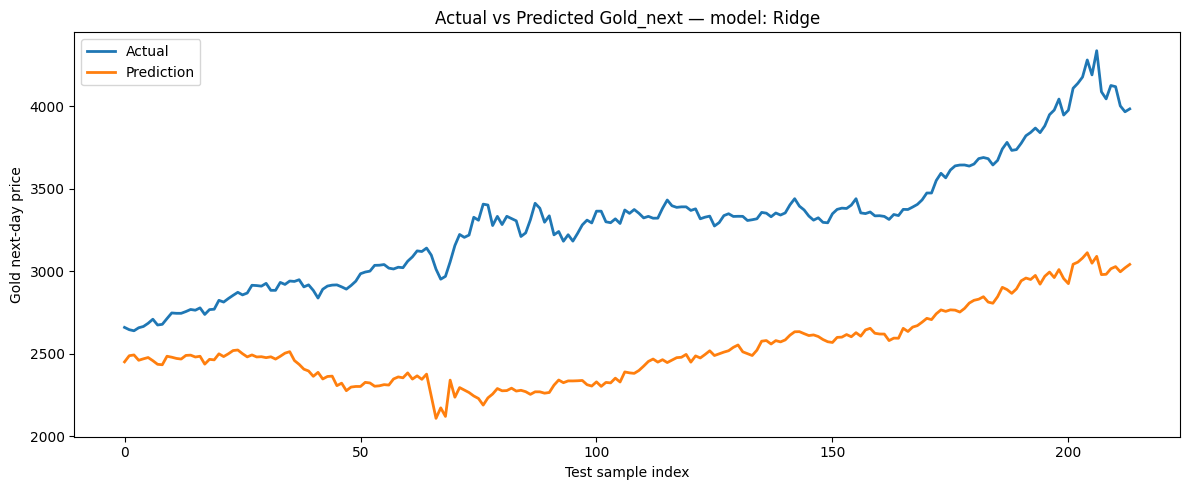

In [59]:
plot_predictions(y_pred_ridge, 'Ridge')

Data histogram.

(array([10., 16., 11.,  9., 12., 49., 50., 30., 21.,  6.]),
 array([ 146.59556284,  256.60655793,  366.61755302,  476.6285481 ,
         586.63954319,  696.65053828,  806.66153337,  916.67252846,
        1026.68352355, 1136.69451864, 1246.70551373]),
 <BarContainer object of 10 artists>)

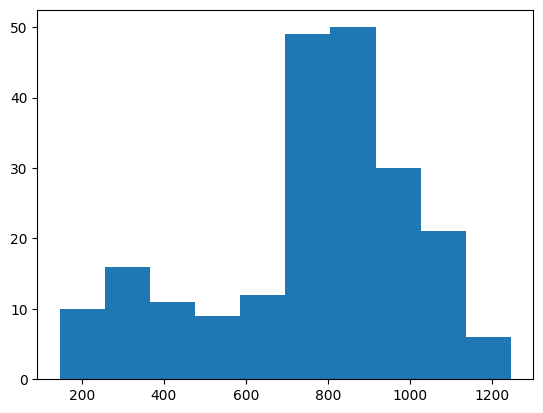

In [ ]:
plt.hist(y_test - y_pred_ridge)
plt.show()

##### Linear Regression model with hyperparameter tuning.

In [61]:
pipeline2 = Pipeline([
    ('prep', PolynomialFeatures()),
    ('scale', StandardScaler()),
    ('model', LinearRegression())
])

parm_grid2 = {
    'prep__degree' : (1,5),
    'prep__interaction_only' : [True, False],
    'prep__include_bias' : [True, False],
    'prep__order' : ['C', 'F'],
    'model__fit_intercept' : [True, False],
    'model__positive' : [True, False]
}

grid2 = GridSearchCV(pipeline2, parm_grid2, cv=5, n_jobs=-1)
grid2.fit(X_train,y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'model__fit_intercept': [True, False], 'model__positive': [True, False], 'prep__degree': (1, ...), 'prep__include_bias': [True, False], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,degree,1


The best model parameters.

In [62]:
grid2.best_params_

{'model__fit_intercept': True,
 'model__positive': True,
 'prep__degree': 1,
 'prep__include_bias': True,
 'prep__interaction_only': True,
 'prep__order': 'F'}

$R^2$ score of the best model

In [63]:
grid2.score(X_train,y_train)

0.9045440077916282

Average $R^2$ score for cross-validation of the best model

In [64]:
grid2.best_score_

np.float64(-0.08042942849161565)

In [65]:
y_pred = grid2.predict(X_test)

Visualization of gold prices and model predictions.

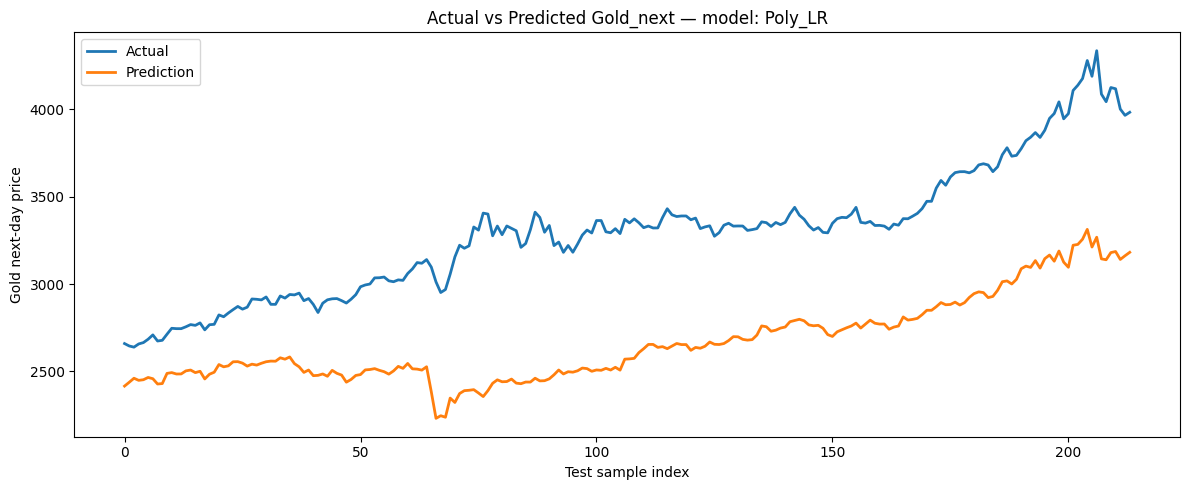

In [66]:
plot_predictions(y_pred, "Poly_LR")

Data histogram.

(array([15., 16., 16., 12., 36., 35., 45., 23., 13.,  3.]),
 array([ 178.15719189,  267.18206689,  356.20694189,  445.2318169 ,
         534.2566919 ,  623.2815669 ,  712.30644191,  801.33131691,
         890.35619191,  979.38106692, 1068.40594192]),
 <BarContainer object of 10 artists>)

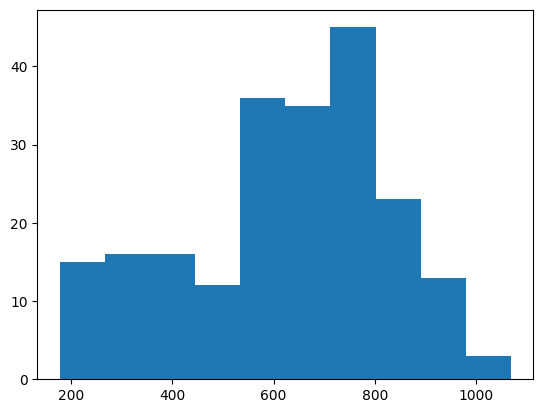

In [ ]:
plt.hist(y_test - y_pred)
plt.show()

In [68]:
grid2.best_estimator_.named_steps['model'].coef_

array([  0.        , 213.22027117,   0.        , 234.9735958 ,
         0.        ,   0.        ,  30.62154753,   0.        ,
         0.        ])

In [69]:
grid2.best_estimator_.named_steps['model'].intercept_

np.float64(1544.8207303224654)

In [70]:
X_train.head()

,Silver,Oil,SP500,Euro_STOXX_50,DAX,USDPLN,EURUSD,USDGBP
Date,,,,,,,,
2010-01-04,17.440001,81.510002,1132.989990,4352.868250,8724.054531,2.8250,1.442398,1.611370
2010-01-05,17.781000,81.769997,1136.520020,4327.544230,8665.345250,2.8453,1.436596,1.599079
2010-01-06,18.163000,83.180000,1137.140015,4335.124196,8691.869213,2.8379,1.440403,1.602384
2010-01-07,18.333000,82.660004,1141.689941,4305.919241,8618.538874,2.8673,1.431803,1.593397
2010-01-08,18.458000,82.750000,1144.979980,4349.051121,8700.854282,2.8182,1.441109,1.602410


In [71]:
slope, intercept, r_value, p_value, std_err = linregress(X_train['Oil'], y_train)

In [72]:
r2 = r_value**2
r2

np.float64(0.03973885708704701)

In [73]:
slope, intercept, r_value, p_value, std_err = linregress(X_test['Oil'], y_test)

In [74]:
r2 = r_value**2
r2

np.float64(0.5052667089430318)

##### Model RandomForestClassifier

Transforming the Y-value of the training and test sets into classes 0 and 1 to ensure the model works correctly.

- 0 - the price of gold decreases
- 1 - the price of gold increases

In [68]:
y_train_disc = (train_df['Gold'].shift(-1) > train_df['Gold']).astype(int)  # 1 if price goes up, 0 if down
y_test_disc = (test_df['Gold'].shift(-1) > test_df['Gold']).astype(int)

In [69]:
tree_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('tree', RandomForestClassifier())
])

tree_grid = {
    "tree__n_estimators" : [10,20,30,50],
    "tree__criterion" : ['gini', 'entropy', 'log_loss'],
    "tree__max_depth" : [2,4,10, None],
    "tree__min_samples_split" : [2,4,6],
    "tree__min_samples_leaf" : [1,2,3,4],
    "tree__max_features" : ['sqrt', 'log2', None]
}

grid_tree = GridSearchCV(tree_pipe,tree_grid, cv=5, n_jobs=-1)
grid_tree.fit(X_train,y_train_disc)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'tree__criterion': ['gini', 'entropy', ...], 'tree__max_depth': [2, 4, ...], 'tree__max_features': ['sqrt', 'log2', ...], 'tree__min_samples_leaf': [1, 2, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


The best model parameters.

In [70]:
grid_tree.get_params()

{'cv': 5,
 'error_score': nan,
 'estimator__memory': None,
 'estimator__steps': [('scaler', StandardScaler()),
  ('tree', RandomForestClassifier())],
 'estimator__transform_input': None,
 'estimator__verbose': False,
 'estimator__scaler': StandardScaler(),
 'estimator__tree': RandomForestClassifier(),
 'estimator__scaler__copy': True,
 'estimator__scaler__with_mean': True,
 'estimator__scaler__with_std': True,
 'estimator__tree__bootstrap': True,
 'estimator__tree__ccp_alpha': 0.0,
 'estimator__tree__class_weight': None,
 'estimator__tree__criterion': 'gini',
 'estimator__tree__max_depth': None,
 'estimator__tree__max_features': 'sqrt',
 'estimator__tree__max_leaf_nodes': None,
 'estimator__tree__max_samples': None,
 'estimator__tree__min_impurity_decrease': 0.0,
 'estimator__tree__min_samples_leaf': 1,
 'estimator__tree__min_samples_split': 2,
 'estimator__tree__min_weight_fraction_leaf': 0.0,
 'estimator__tree__monotonic_cst': None,
 'estimator__tree__n_estimators': 100,
 'estimator_

In [71]:
grid_tree.best_estimator_.get_feature_names_out

<bound method Pipeline.get_feature_names_out of Pipeline(steps=[('scaler', StandardScaler()),
                ('tree',
                 RandomForestClassifier(criterion='log_loss', max_depth=2,
                                        max_features='log2', min_samples_leaf=2,
                                        n_estimators=10))])>

In [72]:
y_tree_pred = grid_tree.predict(X_test)

In [76]:
print(classification_report(y_tree_pred, y_test_disc))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.58      0.73       214

    accuracy                           0.58       214
   macro avg       0.50      0.29      0.37       214
weighted avg       1.00      0.58      0.73       214



##### Model DecisionTreeRegressor.

In [77]:
tree_regressor = Pipeline([
    ('scaler', StandardScaler()),
    ('tree', DecisionTreeRegressor())
])

parm_grid_dtr = {
    'tree__criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'tree__splitter' : ['best'],
    'tree__max_depth' : [2,3,4,5,6,7,8,9,10],
    'tree__max_features' : ['sqrt', 'log2']
}
grid_dtr = GridSearchCV(tree_regressor, parm_grid_dtr, cv=5, n_jobs=-1)
grid_dtr.fit(X_train,y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'tree__criterion': ['squared_error', 'friedman_mse', ...], 'tree__max_depth': [2, 3, ...], 'tree__max_features': ['sqrt', 'log2'], 'tree__splitter': ['best']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


The best model parameters.

In [78]:
grid_dtr.best_params_

{'tree__criterion': 'squared_error',
 'tree__max_depth': 2,
 'tree__max_features': 'log2',
 'tree__splitter': 'best'}

In [79]:
y_pred_dtr = grid_dtr.predict(X_test)

Visualization of gold prices and model predictions.

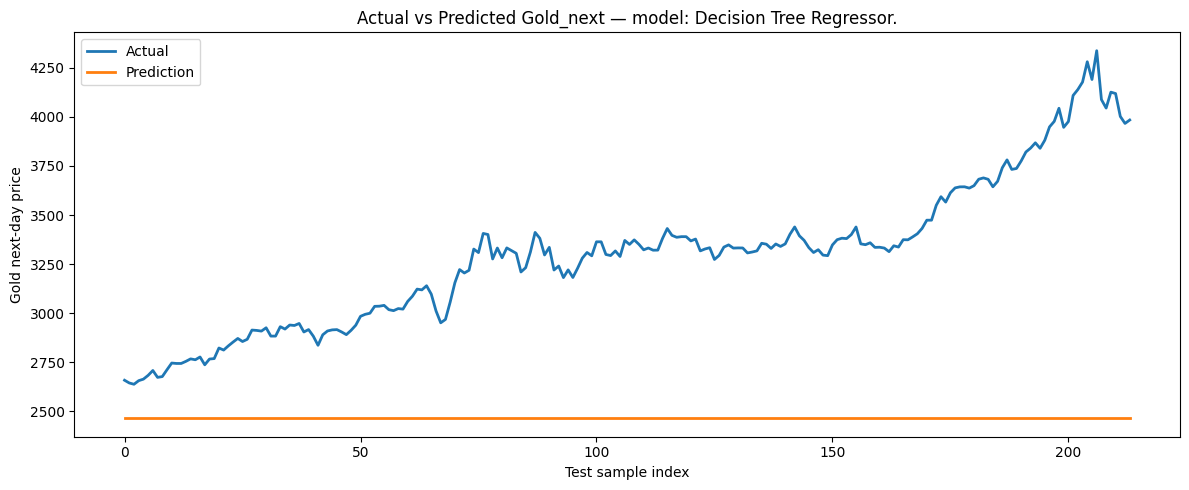

In [82]:
plot_predictions(y_pred_dtr, "Decision Tree Regressor.")

#### Adding Lags to gold prices and rolling mean

| Technique | Purpose | What it gives the model |
|------------|----------|--------------------------|
| **Lag features** | Capture the influence of past values | Memory of short-term dynamics and temporal dependencies |
| **Rolling mean (moving average)** | Smooth out short-term fluctuations and highlight trends | Context of the long-term trend and overall direction |

**In short:**
- **Lags** help the model “remember” how the price has been changing recently.  
- **Rolling means** help it understand whether the market is in an upward or downward trend.  
- **Together**, they make time-series models (e.g., for gold prices) more aware of both short-term momentum and long-term patterns.


In [83]:
TEST_SIZE_RATIO = 0.20
TS_CV_SPLITS = 5
RANDOM_STATE = 42
data = pd.read_csv("data/financial_data_usd_2010-01-01_2025-10-03.csv", parse_dates=['Date'])
data = data.sort_values('Date').reset_index(drop=True)
# lag features (gold)
lags = [1,2,3,7,14]
for l in lags:
    data[f'Gold_lag_{l}'] = data['Gold'].shift(l)

In [84]:
# rolling means
windows = [3,7,14,30]
for w in windows:
    data[f'Gold_roll_mean_{w}'] = data['Gold'].rolling(w).mean()

# pct changes for assets
assets = ['Gold','Silver','Oil','SP500','Euro_STOXX_50','DAX','USDPLN','EURUSD','USDGBP']
for a in assets:
    if a in data.columns:
        data[f'{a}_pct_1'] = data[a].pct_change(1)
        data[f'{a}_pct_7'] = data[a].pct_change(7)

In [85]:
# date features
data['dayofweek'] = data['Date'].dt.dayofweek
data['month'] = data['Date'].dt.month

# target: next day's gold price
data['Gold_next'] = data['Gold'].shift(-1)

# drop NaNs resulted from shifts/rolling
data = data.dropna().reset_index(drop=True)
print("After feature engineering:", data.shape)

After feature engineering: (4096, 40)


In [86]:
# ---------- Prepare X, y and time-based split ----------
exclude = ['Gold','Gold_next', 'Date']
features = [c for c in data.columns if c not in exclude]
X = data[features]
y = data['Gold_next']


In [87]:
split_idx = int(len(data) * (1 - TEST_SIZE_RATIO))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = data['Date'].iloc[split_idx:].reset_index(drop=True)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (3276, 37) Test size: (820, 37)


#### Various models with hyperparameter tuning

In [88]:
models = {}
param_grids = {}

In [89]:
# Decision Tree
models['DecisionTree'] = DecisionTreeRegressor(random_state=RANDOM_STATE)
param_grids['DecisionTree'] = {
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 5]
}

# Random Forest
models['RandomForest'] = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
param_grids['RandomForest'] = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [5, 10, None],
    'model__min_samples_leaf': [1, 2, 5]
}

# Gradient Boosting (sklearn)
models['GradientBoosting'] = GradientBoostingRegressor(random_state=RANDOM_STATE)
param_grids['GradientBoosting'] = {
    'model__n_estimators': [100, 300],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5]
}

# XGBoost if available
models['XGBoost'] = XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
param_grids['XGBoost'] = {
    'model__n_estimators': [100, 300],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5]
}

#### Gridsearch and prediction for provided models.

In [90]:
# ---------- Helper: fit GridSearchCV for each model ----------
tscv = TimeSeriesSplit(n_splits=TS_CV_SPLITS)
results_summary = []

for name, estimator in models.items():
    print("\n--- Running model:", name)
    pipe = Pipeline([
        ('scaler', StandardScaler()),  # scaling is harmless; tree-based not required but fine for comparability
        ('model', estimator)
    ])

    grid = param_grids[name]

    gscv = GridSearchCV(pipe, grid, cv=tscv, scoring='neg_mean_absolute_error',
                        n_jobs=4, verbose=2, refit=True)

    # Warning for runtime
    print(f"Fitting GridSearch for {name} — this can take a while depending on grid size and data length.")
    gscv.fit(X_train, y_train)

    best = gscv.best_estimator_
    print(f"{name} best params:", gscv.best_params_)

    # Predict and evaluate on test set
    y_pred = best.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results_summary.append({
        'model': name,
        'best_params': gscv.best_params_,
        'mse': mse,
        'mae': mae,
        'r2': r2
    })

    # Save predictions sample
    pred_df = pd.DataFrame({
        'Date': dates_test,
        'Gold_actual': y_test.values,
        f'Gold_pred_{name}': y_pred
    })
    
    # Feature importances (for tree-based)
    try:
        model_step = best.named_steps['model']
        if hasattr(model_step, "feature_importances_"):
            importances = model_step.feature_importances_
            fi = pd.DataFrame({'feature': features, 'importance': importances}).sort_values('importance', ascending=False)
        else:
            # for linear models we could dump coef_
            pass
    except Exception as e:
        print("Couldn't extract feature importances for", name, e)


--- Running model: DecisionTree
Fitting GridSearch for DecisionTree — this can take a while depending on grid size and data length.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.0s
[CV] END model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.0s
[CV] END model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.0s
[CV] END model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.0s
[CV] END model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=5; total time=   0.0s
[CV] END model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.0s
[CV] END model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=5; total time=   0.0s
[CV] END model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=5; 

Summary dataframe of the best models parameters with losses.

In [91]:
res_df = pd.DataFrame(results_summary).sort_values('mae')
print("\nModels comparison:")
print(res_df)


Models comparison:
              model                                        best_params  \
0      DecisionTree  {'model__max_depth': 5, 'model__min_samples_le...   
2  GradientBoosting  {'model__learning_rate': 0.1, 'model__max_dept...   
1      RandomForest  {'model__max_depth': 5, 'model__min_samples_le...   
3           XGBoost  {'model__learning_rate': 0.1, 'model__max_dept...   

             mse         mae        r2  
0  557781.170317  485.127848 -0.492333  
2  565557.928436  489.130350 -0.513139  
1  574671.972471  496.158890 -0.537524  
3  578223.549487  497.104398 -0.547026  


Plots: Actual vs Predicted for each model and residuals.

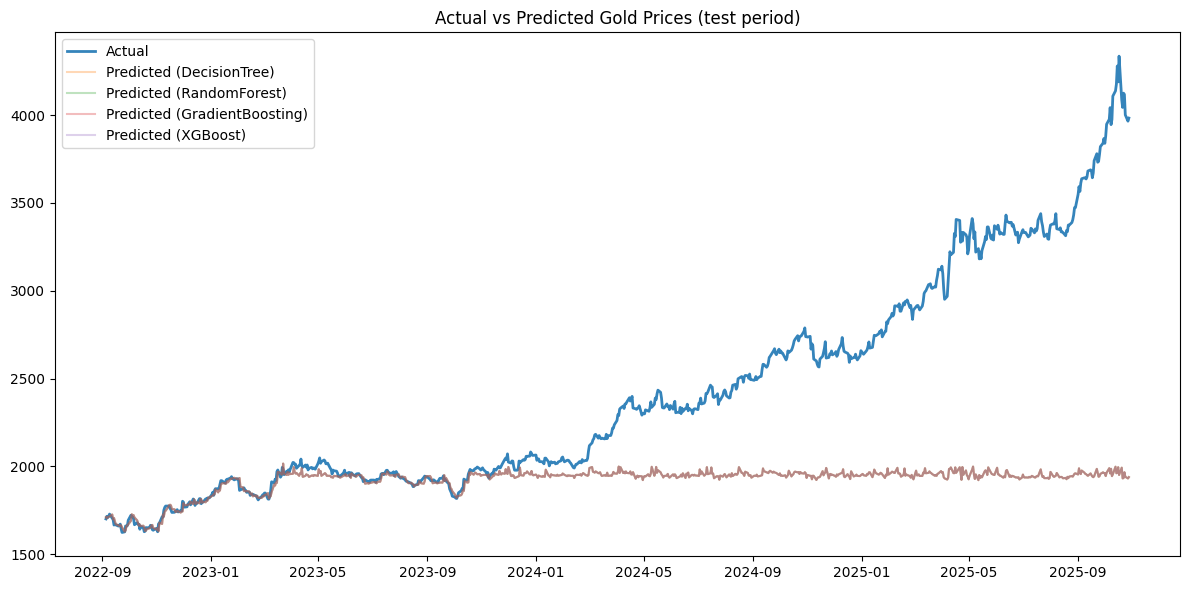

In [92]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test.values, label='Actual', linewidth=2, alpha=0.9)

for name in models.keys():
    plt.plot(pred_df['Date'], pred_df.iloc[:,2], label=f'Predicted ({name})', alpha=0.3)

plt.title('Actual vs Predicted Gold Prices (test period)')
plt.legend()
plt.tight_layout()
plt.show()

Residuals histograms and MAE bar chart.

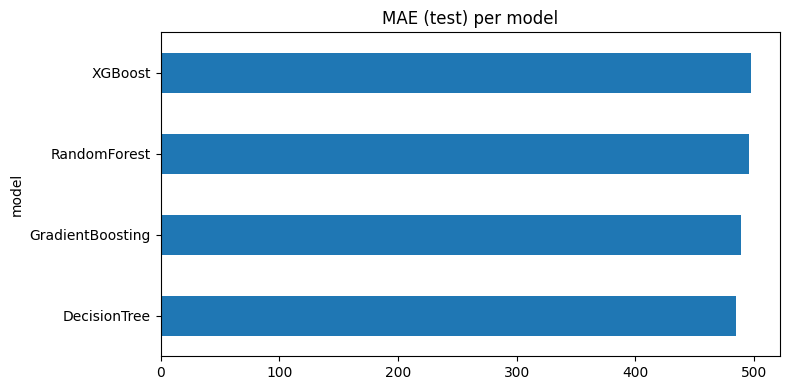

In [93]:
mae_vals = res_df.set_index('model')['mae']
plt.figure(figsize=(8,4))
mae_vals.plot(kind='barh')
plt.title('MAE (test) per model')
plt.tight_layout()
plt.show()

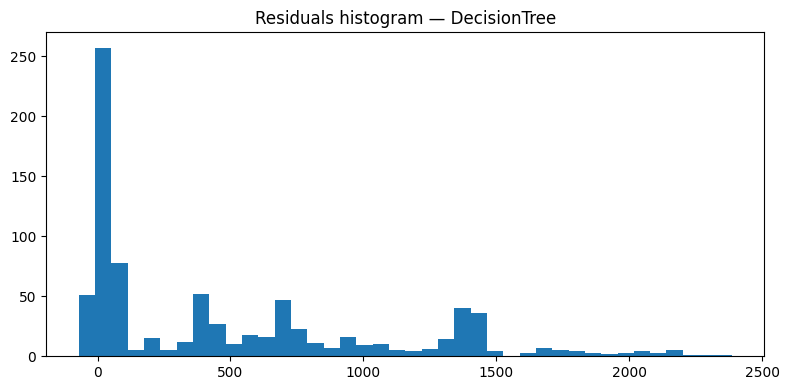

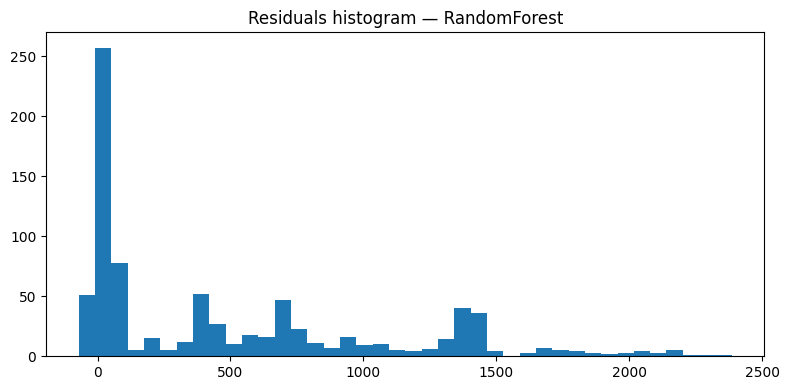

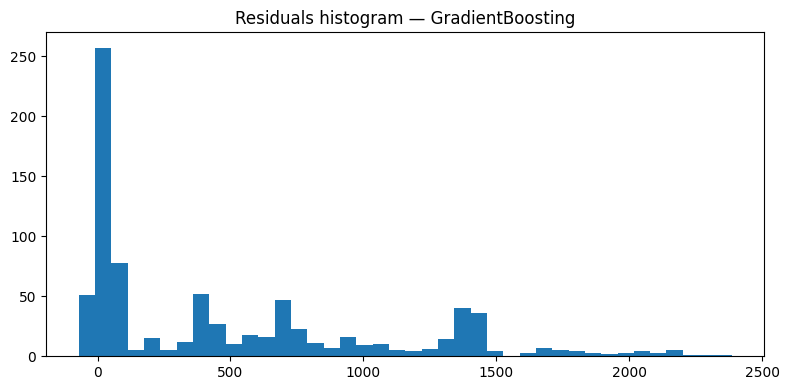

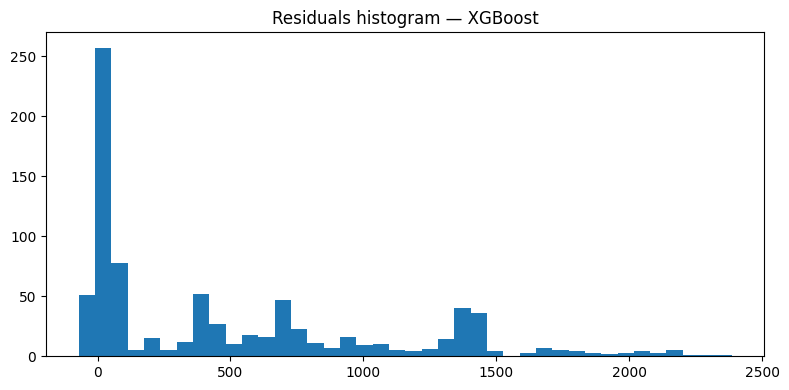

In [94]:

for name in models.keys():
    p = pred_df
    residuals = p['Gold_actual'].values - p.iloc[:,2].values
    plt.figure(figsize=(8,4))
    plt.hist(residuals, bins=40)
    plt.title(f'Residuals histogram — {name}')
    plt.tight_layout()
    plt.show()


#### Abandoning timeseries, data entered into the model in a random manner.

In [95]:
TEST_SIZE = 0.2
POLY_DEGREE = 3
RANDOM_STATE = 42
# ------------------------------------------

In [96]:
# Lags for Gold
lags = [1, 2, 3, 7, 14]
for l in lags:
    data[f'Gold_lag_{l}'] = data['Gold'].shift(l)

In [97]:
# Rolling means for Gold
windows = [3, 7, 14, 30]
for w in windows:
    data[f'Gold_roll_mean_{w}'] = data['Gold'].rolling(w).mean()

In [98]:
# pct changes for assets (if columns exist)
assets = ['Gold', 'Silver', 'Oil', 'SP500', 'Euro_STOXX_50', 'DAX', 'USDPLN', 'EURUSD', 'USDGBP']
for a in assets:
    if a in data.columns:
        data[f'{a}_pct_1'] = data[a].pct_change(1)
        data[f'{a}_pct_7'] = data[a].pct_change(7)

In [99]:
# Target: Gold next day (absolute value), then remove Date column per request
data['Gold_next'] = data['Gold'].shift(-1)

In [100]:
# Drop Date column completely
if 'Date' in data.columns:
    data = data.drop(columns=['Date'])

In [101]:
# Drop rows with NaN from lags/rolling/pct
data = data.dropna().reset_index(drop=True)

print("After feature engineering, rows:", len(data), "columns:", data.shape[1])

After feature engineering, rows: 4066 columns: 39


In [102]:
# Features and target
TARGET = "Gold_next"  # we predict next-day Gold, then evaluate vs actual Gold_next
X = data.drop(columns=[TARGET, 'Gold'])  # keep numeric features (drop original 'Gold' to avoid leakage to absolute value)
y = data[TARGET].values

In [103]:
# Train/test split with shuffle=True as requested
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (3252, 37) Test shape: (814, 37)


In [104]:
# 2) Define models
models_to_run = {}

In [105]:
# Linear models (no heavy grid)
models_to_run['LinearRegression'] = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])

In [106]:
# Ridge and Lasso (we will do simple grid for alpha)
models_to_run['Ridge'] = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(random_state=RANDOM_STATE))])
models_to_run['Lasso'] = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(random_state=RANDOM_STATE, max_iter=10000))])

In [107]:
# Polynomial + Linear / Ridge / Lasso (degree=3)
models_to_run['Poly_LR'] = Pipeline([('poly', PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
                                     ('scaler', StandardScaler()), ('lr', LinearRegression())])
models_to_run['Poly_Ridge'] = Pipeline([('poly', PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
                                       ('scaler', StandardScaler()), ('ridge', Ridge(random_state=RANDOM_STATE))])
models_to_run['Poly_Lasso'] = Pipeline([('poly', PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
                                       ('scaler', StandardScaler()), ('lasso', Lasso(random_state=RANDOM_STATE, max_iter=10000))])

In [108]:
# Tree-based models (we'll use GridSearchCV for these)
models_tree = {
    'DecisionTree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost' : XGBRegressor(random_state=RANDOM_STATE, verbosity=1)
}

In [109]:
# 3) Param grids
param_grids_tree = {
    'DecisionTree': {
        'model__max_depth': [None, 5, 10],
        'model__min_samples_leaf': [1, 3, 5]
    },
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10],
        'model__min_samples_leaf': [1, 3]
    },
    'GradientBoosting': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1],
        'model__max_depth': [3, 5]
    },
    'XGBoost' : {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1],
        'model__max_depth': [3, 5]
    }
}

In [110]:
# For Ridge/Lasso small grid on alpha
param_grid_ridge = {'ridge__alpha': [0.1, 1.0, 10.0]}
param_grid_lasso = {'lasso__alpha': [0.001, 0.01, 0.1, 1.0]}

In [111]:
# 4) Fit linear-type models (no GridSearch) except Ridge/Lasso (we'll GridSearch alpha)
results = []
fitted_models = {}

In [112]:
# Linear Regression
print("\nFitting LinearRegression...")
models_to_run['LinearRegression'].fit(X_train, y_train)
fitted_models['LinearRegression'] = models_to_run['LinearRegression']


Fitting LinearRegression...


In [113]:
# Poly LR
print("Fitting Poly (deg={}) + LinearRegression...".format(POLY_DEGREE))
models_to_run['Poly_LR'].fit(X_train, y_train)
fitted_models['Poly_LR'] = models_to_run['Poly_LR']

Fitting Poly (deg=3) + LinearRegression...


In [114]:
# Ridge GridSearch
print("GridSearch Ridge...")
gs_ridge = GridSearchCV(models_to_run['Ridge'], param_grid_ridge, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1, refit=True, verbose=1)
gs_ridge.fit(X_train, y_train)
fitted_models['Ridge'] = gs_ridge.best_estimator_
best_ridge_params = gs_ridge.best_params_

GridSearch Ridge...
Fitting 5 folds for each of 3 candidates, totalling 15 fits


In [115]:
# Lasso GridSearch
print("GridSearch Lasso...")
gs_lasso = GridSearchCV(models_to_run['Lasso'], param_grid_lasso, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1, refit=True, verbose=1)
gs_lasso.fit(X_train, y_train)
fitted_models['Lasso'] = gs_lasso.best_estimator_
best_lasso_params = gs_lasso.best_params_

GridSearch Lasso...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [116]:
# Poly + Ridge/Lasso (GridSearch for alpha)
print("GridSearch Poly + Ridge/Lasso...")
poly_ridge_pipeline = models_to_run['Poly_Ridge']
poly_lasso_pipeline = models_to_run['Poly_Lasso']

gs_poly_ridge = GridSearchCV(poly_ridge_pipeline, {'ridge__alpha': [0.1, 1.0, 10.0]}, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1, refit=True, verbose=1)
gs_poly_ridge.fit(X_train, y_train)
fitted_models['Poly_Ridge'] = gs_poly_ridge.best_estimator_
best_poly_ridge_params = gs_poly_ridge.best_params_

gs_poly_lasso = GridSearchCV(poly_lasso_pipeline, {'lasso__alpha': [0.001, 0.01, 0.1, 1.0]}, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1, refit=True, verbose=1)
gs_poly_lasso.fit(X_train, y_train)
fitted_models['Poly_Lasso'] = gs_poly_lasso.best_estimator_
best_poly_lasso_params = gs_poly_lasso.best_params_

GridSearch Poly + Ridge/Lasso...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [117]:
# Evaluate linear-family models
linear_models = ['LinearRegression', 'Ridge', 'Lasso', 'Poly_LR', 'Poly_Ridge', 'Poly_Lasso']
for name in linear_models:
    model = fitted_models[name]
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'model': name, 'mse': mse, 'mae': mae, 'r2': r2, 'best_params': None})
    print(f"{name} -> MAE: {mae:.3f}, MSE: {mse:.3f}, R2: {r2:.4f}")

LinearRegression -> MAE: 12.143, MSE: 396.486, R2: 0.9985
Ridge -> MAE: 12.534, MSE: 394.196, R2: 0.9985
Lasso -> MAE: 12.832, MSE: 398.192, R2: 0.9985
Poly_LR -> MAE: 71.919, MSE: 45668.412, R2: 0.8260
Poly_Ridge -> MAE: 23.548, MSE: 4938.437, R2: 0.9812
Poly_Lasso -> MAE: 12.324, MSE: 396.210, R2: 0.9985


In [118]:
# 5) Fit tree-based models with GridSearch
print("\nGridSearch for tree-based models (this may take some time)...")
for name, estimator in models_tree.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', estimator)])
    grid = param_grids_tree[name]
    gscv = GridSearchCV(pipe, grid, scoring='neg_mean_absolute_error', cv=5, verbose=2, refit=True)
    print(f"\nFitting {name} ...")
    gscv.fit(X_train, y_train)
    best = gscv.best_estimator_
    fitted_models[name] = best
    # Evaluate
    y_pred = best.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'model': name, 'mse': mse, 'mae': mae, 'r2': r2, 'best_params': gscv.best_params_})
    print(f"{name} best params: {gscv.best_params_}")
    print(f"{name} -> MAE: {mae:.3f}, MSE: {mse:.3f}, R2: {r2:.4f}")



GridSearch for tree-based models (this may take some time)...

Fitting DecisionTree ...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...model__max_depth=None, model__min_samples_leaf=1; total time=   0.1s
[CV] END ...model__max_depth=None, model__min_samples_leaf=1; total time=   0.1s
[CV] END ...model__max_depth=None, model__min_samples_leaf=1; total time=   0.1s
[CV] END ...model__max_depth=None, model__min_samples_leaf=1; total time=   0.1s
[CV] END ...model__max_depth=None, model__min_samples_leaf=1; total time=   0.1s
[CV] END ...model__max_depth=None, model__min_samples_leaf=3; total time=   0.1s
[CV] END ...model__max_depth=None, model__min_samples_leaf=3; total time=   0.1s
[CV] END ...model__max_depth=None, model__min_samples_leaf=3; total time=   0.1s
[CV] END ...model__max_depth=None, model__min_samples_leaf=3; total time=   0.1s
[CV] END ...model__max_depth=None, model__min_samples_leaf=3; total time=   0.1s
[CV] END ...model__max_depth=None, model_

In [119]:
# 6) Collect tree-grid best params and linear-grid params
# add best params for Ridge/Lasso combos
# update results for the linear ones with their best params where applicable
for r in results:
    if r['model'] == 'Ridge':
        r['best_params'] = best_ridge_params
    if r['model'] == 'Lasso':
        r['best_params'] = best_lasso_params
    if r['model'] == 'Poly_Ridge':
        r['best_params'] = best_poly_ridge_params
    if r['model'] == 'Poly_Lasso':
        r['best_params'] = best_poly_lasso_params


In [120]:
# 7) Final results table
final_df = pd.DataFrame(results).sort_values('mae').reset_index(drop=True).round(4)
print(final_df[['model', 'mae', 'mse', 'r2', 'best_params']])

              model      mae         mse      r2  \
0  LinearRegression  12.1435    396.4858  0.9985   
1        Poly_Lasso  12.3244    396.2096  0.9985   
2             Ridge  12.5336    394.1965  0.9985   
3             Lasso  12.8324    398.1919  0.9985   
4  GradientBoosting  13.2204    397.4213  0.9985   
5           XGBoost  13.4215    427.2165  0.9984   
6      RandomForest  13.8256    445.6333  0.9983   
7      DecisionTree  17.7872    738.9466  0.9972   
8        Poly_Ridge  23.5484   4938.4365  0.9812   
9           Poly_LR  71.9187  45668.4125  0.8260   

                                         best_params  
0                                               None  
1                              {'lasso__alpha': 1.0}  
2                              {'ridge__alpha': 0.1}  
3                              {'lasso__alpha': 1.0}  
4  {'model__learning_rate': 0.1, 'model__max_dept...  
5  {'model__learning_rate': 0.1, 'model__max_dept...  
6  {'model__max_depth': None, 'model__min_


Best model by MAE: LinearRegression


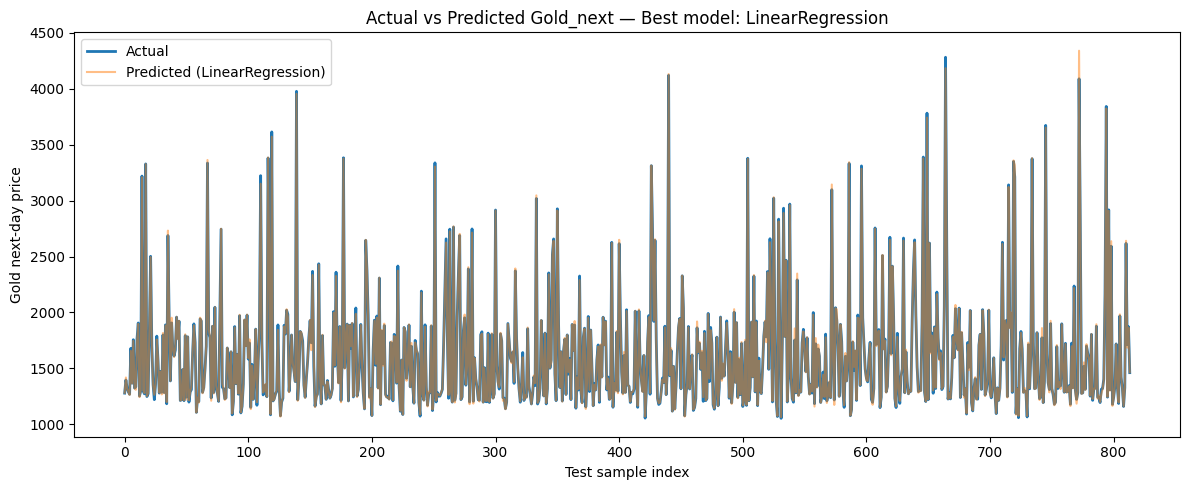

In [121]:
# 8) Plot: Actual vs Predicted for the best model (by MAE)
best_row = final_df.iloc[0]
best_model_name = best_row['model']
print("\nBest model by MAE:", best_model_name)

best_model = fitted_models[best_model_name]
y_best_pred = best_model.predict(X_test)

plt.figure(figsize=(12,5))
plt.plot(range(len(y_test)), y_test, label='Actual', linewidth=2)
plt.plot(range(len(y_test)), y_best_pred, label=f'Predicted ({best_model_name})', alpha=0.5)
plt.title(f'Actual vs Predicted Gold_next — Best model: {best_model_name}')
plt.xlabel('Test sample index')
plt.ylabel('Gold next-day price')
plt.legend()
plt.tight_layout()
plt.show()

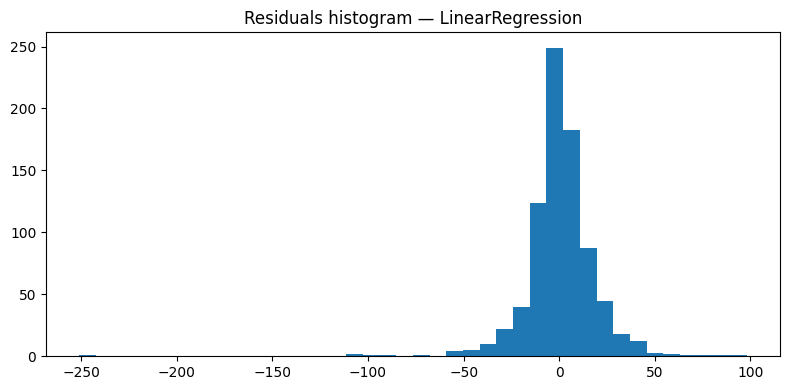

In [122]:
# Residuals histogram
residuals = y_test - y_best_pred
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=40)
plt.title(f'Residuals histogram — {best_model_name}')
plt.tight_layout()
plt.show()

In [123]:
# 9) Save predictions of best model with original index reference
preds_df = pd.DataFrame({
    'Gold_actual': y_test,
    'Gold_pred': y_best_pred,
    'residual': residuals
})

In [124]:
display(preds_df)

,Gold_actual,Gold_pred,residual
0,1279.400024,1281.871886,-2.471862
1,1396.699951,1418.973033,-22.273082
2,1324.500000,1318.018461,6.481539
3,1290.699951,1293.025766,-2.325815
4,1269.199951,1263.348358,5.851593
...,...,...,...
809,1327.199951,1316.380147,10.819804
810,2617.199951,2640.392246,-23.192295
811,1713.800049,1685.817627,27.982422
812,1872.599976,1865.039912,7.560063


In [125]:
fitted_models

{'LinearRegression': Pipeline(steps=[('scaler', StandardScaler()), ('lr', LinearRegression())]),
 'Poly_LR': Pipeline(steps=[('poly', PolynomialFeatures(degree=3, include_bias=False)),
                 ('scaler', StandardScaler()), ('lr', LinearRegression())]),
 'Ridge': Pipeline(steps=[('scaler', StandardScaler()),
                 ('ridge', Ridge(alpha=0.1, random_state=42))]),
 'Lasso': Pipeline(steps=[('scaler', StandardScaler()),
                 ('lasso', Lasso(max_iter=10000, random_state=42))]),
 'Poly_Ridge': Pipeline(steps=[('poly', PolynomialFeatures(degree=3, include_bias=False)),
                 ('scaler', StandardScaler()),
                 ('ridge', Ridge(alpha=10.0, random_state=42))]),
 'Poly_Lasso': Pipeline(steps=[('poly', PolynomialFeatures(degree=3, include_bias=False)),
                 ('scaler', StandardScaler()),
                 ('lasso', Lasso(max_iter=10000, random_state=42))]),
 'DecisionTree': Pipeline(steps=[('scaler', StandardScaler()),
                

In [126]:
results_df = pd.DataFrame(results).round(4)

In [127]:
results_df

,model,mse,mae,r2,best_params
0,LinearRegression,396.4858,12.1435,0.9985,None
1,Ridge,394.1965,12.5336,0.9985,{'ridge__alpha': 0.1}
2,Lasso,398.1919,12.8324,0.9985,{'lasso__alpha': 1.0}
3,Poly_LR,45668.4125,71.9187,0.8260,None
4,Poly_Ridge,4938.4365,23.5484,0.9812,{'ridge__alpha': 10.0}
5,Poly_Lasso,396.2096,12.3244,0.9985,{'lasso__alpha': 1.0}
6,DecisionTree,738.9466,17.7872,0.9972,"{'model__max_depth': 10, 'model__min_samples_l..."
7,RandomForest,445.6333,13.8256,0.9983,"{'model__max_depth': None, 'model__min_samples..."
8,GradientBoosting,397.4213,13.2204,0.9985,"{'model__learning_rate': 0.1, 'model__max_dept..."
9,XGBoost,427.2165,13.4215,0.9984,"{'model__learning_rate': 0.1, 'model__max_dept..."


#### Summary

  This project applies regression and ensemble models to predict gold prices. Experiments revealed that while models achieve near-perfect R² (≈0.999) under random validation, they collapse under true time-series testing (R² between –0.525 and –0.479). The study highlights the critical impact of validation strategy on performance interpretation and shows how non-stationary data can mislead model evaluation. The work emphasizes careful temporal validation and recommends routes for improving robustness and interpretability.

#### Model Evaluation Metrics for Regression

##### 📊 Overview
MSE, MAE, and R² are fundamental metrics used to evaluate the performance of regression models in machine learning and statistics.

##### 📈 Metrics Breakdown

##### 1. MSE (Mean Squared Error)
- **Definition**: Average of the **squared differences** between predicted and actual values
- **Formula**: `MSE = (1/n) * Σ(actual - predicted)²`
- **Interpretation**:
  - Heavily penalizes large errors (due to squaring)
  - Lower values indicate better performance
  - Sensitive to outliers
- **Use Case**: "How close are predictions to actual values, with emphasis on major errors?"

##### 2. MAE (Mean Absolute Error)
- **Definition**: Average of the **absolute differences** between predicted and actual values
- **Formula**: `MAE = (1/n) * Σ|actual - predicted|`
- **Interpretation**:
  - Treats all errors equally
  - More robust to outliers than MSE
  - Easier to interpret (same units as original data)
  - Lower values indicate better performance
- **Use Case**: "On average, how far off are my predictions?"

##### 3. R² (R-Squared / Coefficient of Determination)
- **Definition**: Proportion of variance in the dependent variable explained by the model
- **Formula**: `R² = 1 - (SS_residual / SS_total)`
- **Interpretation**:
  - **R² = 1**: Perfect fit (model explains all variance)
  - **R² = 0**: No better than predicting the mean
  - **R² < 0**: Worse than predicting the mean
  - Higher values indicate better performance
- **Use Case**: "What percentage of data variation does my model explain?"

#### 🎯 Quick Comparison

| Metric | Range | Ideal Value | Units | Robust to Outliers |
|--------|-------|-------------|--------|-------------------|
| **MSE** | [0, ∞) | 0 | Squared units | ❌ No |
| **MAE** | [0, ∞) | 0 | Original units | ✅ Yes |
| **R²** | (-∞, 1] | 1 | Unitless | ❌ No |

#### 💡 Key Insights
- Use **MSE** when large errors are particularly undesirable
- Use **MAE** when you want interpretability and outlier resistance  
- Use **R²** to understand the explanatory power of your model
- Often best to report multiple metrics for comprehensive evaluation

Visualization of analysis results.

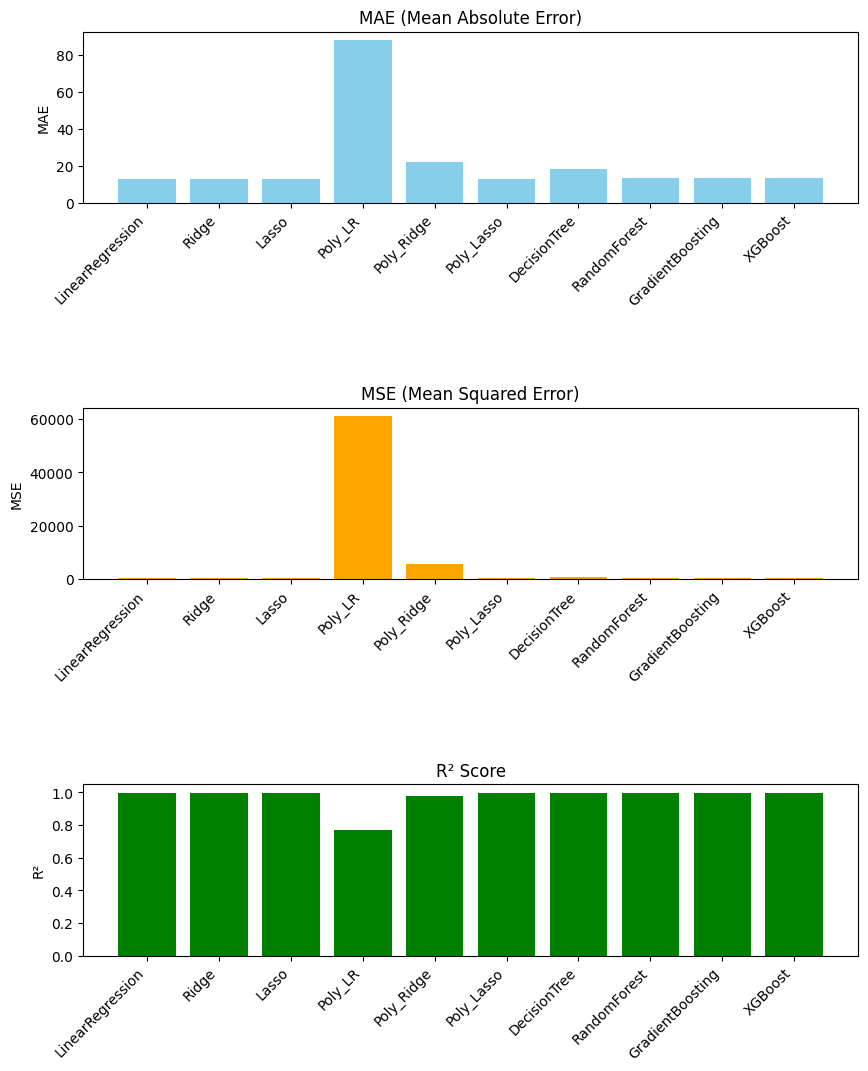

In [149]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
plt.subplots_adjust(hspace=1.2)

# Histogram MAE
axes[0].bar(results_df["model"], results_df["mae"], color="skyblue")
axes[0].set_title("MAE (Mean Absolute Error)")
axes[0].set_ylabel("MAE")
axes[0].set_xticklabels(results_df["model"], rotation=45, ha="right")

# Histogram MSE
axes[1].bar(results_df["model"], results_df["mse"], color="orange")
axes[1].set_title("MSE (Mean Squared Error)")
axes[1].set_ylabel("MSE")
axes[1].set_xticklabels(results_df["model"], rotation=45, ha="right")

# Histogram R²
axes[2].bar(results_df["model"], results_df["r2"], color="green")
axes[2].set_title("R² Score")
axes[2].set_ylabel("R²")
axes[2].set_xticklabels(results_df["model"], rotation=45, ha="right")

plt.show()

#### Conclusion

- Under **time-series (chronological) validation**, models that looked reasonable in-sample performed **very poorly out-of-sample**, with reported **R² values ranging approximately from -0.525 to -0.479**. This indicates extreme overfitting to historical patterns and/or strong non-stationarity in the gold price series.
- By contrast, when the data were **randomly shuffled** and split, models reached **very high R² (≈0.998–0.999)** and low MAE (~11–12). This demonstrates that the models are learning short-term correlations rather than true forward-predictive structure.

- **Temporal instability:** The gold price series exhibits strong regime changes, making standard ML regressors unreliable for true forecasting.  
- **Feature leakage avoidance:** Time-based validation confirmed that lag features must be handled carefully to avoid future data leakage.  
- **Interpretability focus:** Even though temporal prediction failed, the random-split experiments were valuable for understanding **feature relevance** and **model behavior**.  
- **Regularization impact:** Ridge and Lasso maintained similar patterns to tree-based models, implying most signal was linear and short-term.

#### Key Lessons

1. **High R² doesn’t mean predictability:** Random-split evaluation creates an illusion of performance; real-world generalization requires time-aware validation.  
2. **Financial time series ≠ stationary signals:** Relationships between features and target evolve; no static model can capture long-term structure without adaptation.  
3. **Useful outcome:** Even without accurate forecasts, the experiment yielded strong insights into feature dynamics and model sensitivity.  
4. **Future work:** Consider models that explicitly handle non-stationarity (e.g., recurrent neural networks, transformers, or dynamic regressors) and re-train adaptively.